In [1]:
import numpy as np
import scipy.stats as stats
from scipy.io import loadmat
import matplotlib.pyplot as plt
from particles_cdssm.sdes import MvEllipticSDE, IntegratedSDE

# The model

\begin{align}
dV_t &= \frac{1}{\epsilon} (V_t - V_t^3 - U_t - s) dt \\
dU_t &=(\gamma V_t - U_t + \beta) dt + \sigma dB_t
\end{align}

We have parameter vector $\theta = (\epsilon, \gamma, \beta, \sigma)$

# Real data

The data: neural recordings of a rat under cutaneous stimulation, for 250ms (0.25s) at a sampling rate of 500kHz (500000 per second). So we have 125000 observations. Note: in the real data, they say that the subsampling rate is 50kHz, but this is not the case. Record 1554: cutaneous stimulation.

- Column 1: Time
- Columns 2-6: Recordings at different locations.

Fitted parameters from Samson et al (2025):
$\theta = (\epsilon, \gamma, \beta, \sigma) = (0.028, 6.272, 3.670, 0.103)$

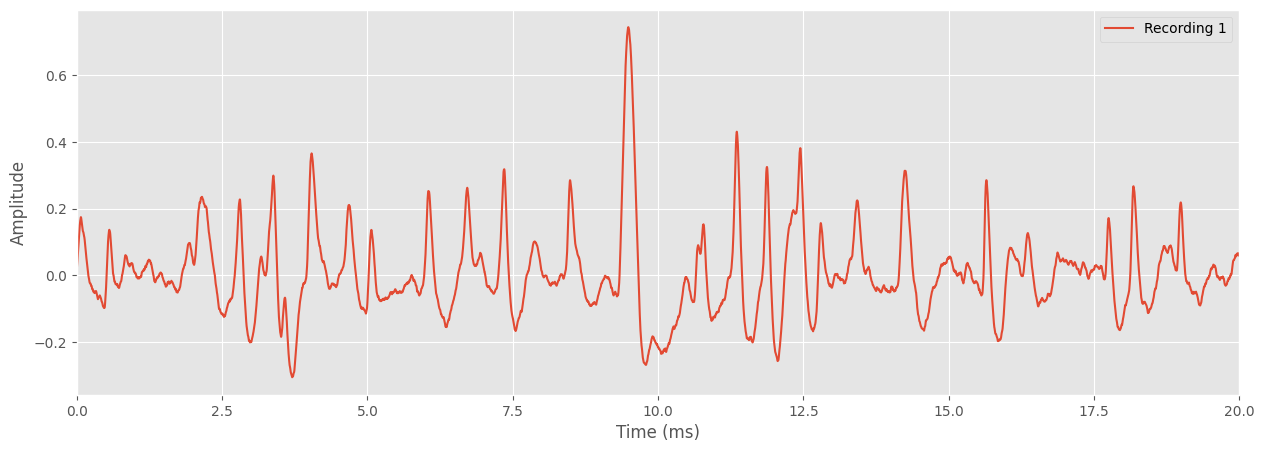

In [2]:
plt.style.use('ggplot')
data_set = loadmat("./data/cutaneous_stimulation/1554.mat") 
raw_data = data_set['rawdata'] # Original array

time = raw_data[:, 0] * 1e3 # Time in ms
recordings = raw_data[:, 1:] # Recordings at different locations

fig, ax = plt.subplots(1, 1, figsize=(15, 5), sharex=True)

delta = 2e-3 # Data is available in increments of 0.002ms (500kHz sampling rate)
t_start = 0.0
t_end = 20.0 # 4ms

start_idx = int(t_start/delta)
n_times = int((t_end - t_start)/delta)
end_idx = start_idx + n_times

ax.plot(time[start_idx:end_idx], recordings[start_idx:end_idx, 0], label=f'Recording {1}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_xlim((t_start, t_end))
ax.legend()

plt.show()

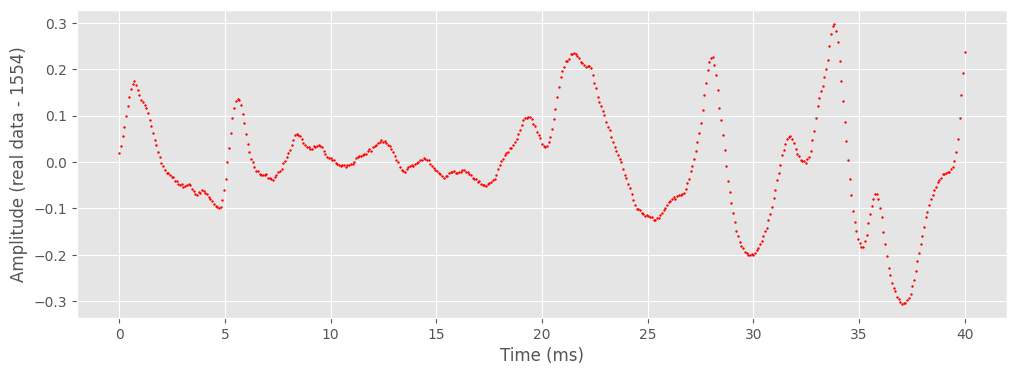

In [3]:
data_set = loadmat("./data/cutaneous_stimulation/1554.mat") 
raw_data = data_set['rawdata']

dt_original = 0.02
dt_data = 0.08
t_max = 40
t_seq_data = np.arange(int(t_max / dt_data) + 1) * dt_data
t_seq_original = np.arange(int(t_max / dt_original) + 1) * dt_original

num_obs = int(t_max / dt_original +1)
y_obs_original = raw_data[:num_obs,1] 
y_obs_sparse = y_obs_original[::int(dt_data/dt_original)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_seq_data, y_obs_sparse, linestyle='None', color='r', marker='+', markersize=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (real data - 1554)')
plt.show()

# Simulated data

In [4]:
class FitzHughNagumo(MvEllipticSDE):
    """
    Stochastic Fitzhugh-Nagumo model, as in Samson et al (2025)
    
    https://www.sciencedirect.com/science/article/pii/S0167947324001798?via%3Dihub

    dV_t = 1/epsilon * (V_t - V_t^3 - U_t) dt
    dU_t = gamma * V_t - U_t + beta dt + sigma_u dB_t
    """
    dimX = 2
    default_params = {'epsilon': 0.1,
                      'gamma': 1.5,
                      'beta': 0.8,
                      'sigma_u': 0.3
                    }

    def b(self, t, x):
        x_1 = 1/self.epsilon * (x[:, 0] - (x[:, 0] ** 3) - x[:, 1]) # (N, )
        x_2 = self.gamma * x[:, 0] - x[:, 1] + self.beta # (N, )
        return np.stack([x_1, x_2], axis=1)

    def sigma(self, t, x):
        N = x.shape[0]
        return np.stack([np.array([[0.0, 0.0], [0.0, self.sigma_u]])]*N, axis=0)
    
    # def db(self, t, x):
    #     N = x.shape[0]
    #     db_1_dx_1 = self.rho[0] * (3 * (x[:, 0] ** 2) + 1) # (N, )
    #     db_1_dx_2 = np.array([-self.rho[1]]*N)
    #     db_2_dx_1 = np.array([self.rho[2]]*N)
    #     db_2_dx_2 = np.array([-1.]*N)
    #     db = np.stack([db_1_dx_1, db_1_dx_2, db_2_dx_1, db_2_dx_2], axis=1).reshape(N, 2, 2)
    #     return db
        
    # def dsigma(self, t, x):
    #     N = x.shape[0]
    #     return np.zeros((N, self.dimX, self.dimX, self.dimX))

In [5]:
# V_0 
v_0 = recordings[0, 0]

# Z_0: Gradient of V at the first time point
z_0 = (recordings[20, 0] - recordings[0, 0])/(time[20] - time[0])


# U_t = V_t - V_t^3 - \epsilon Z_t - s
def Z_to_U(V_t, Z_t, eps=0.028, sigma_u = 0.103):
    """
    return V_t - V_t**3 - eps * Z_t
    """
    return V_t - V_t**3 - eps * Z_t

u_0 = Z_to_U(v_0, z_0, eps=0.028, sigma_u=0.103)

In [6]:
t_start = 0.; t_end = 100
delta_t = 0.002 # Same as the real data sampling rate
num = int((t_end - t_start) / delta_t)
times = np.linspace(t_start, t_end, num)

# params = {'epsilon': 0.028, 'gamma': 6.272, 'beta': 3.670, 'sigma_u': 0.103}
sde = FitzHughNagumo()

# np.random.seed(42)  # For reproducibility

x_0 = np.array([[v_0, u_0]])
x_0 = np.zeros((1, 2))

samples = sde.simulate(1, t_start=t_start, t_end=t_end, x_start=x_0 , num=num)
samples_arr = np.array([samples[name] for name in samples.dtype.names])[:, 0, :]

We need to determine a subsampling rate such that it is necessary to use data augmentation to infer the path of the diffusion process. A visualisation of a simulation of the true process, along with subsamples from the true process are useful in this direction:

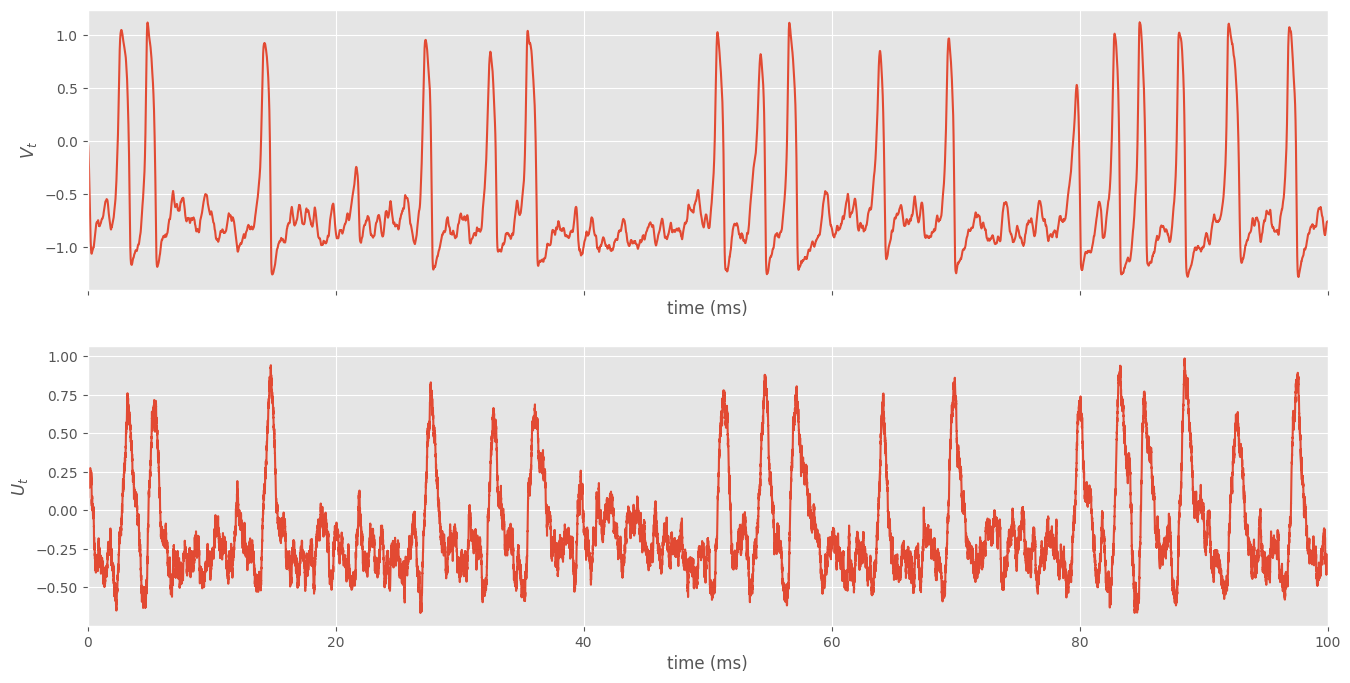

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, squeeze=True)

subsample_delta_t = 0.5
sample_rate = int(subsample_delta_t / delta_t)

axes[0].plot(times, samples_arr[:, 0], label=r'$V_t$')
axes[1].plot(times, samples_arr[:, 1], label=r'$U_t$')

# axes[0].plot(times[::sample_rate], samples_arr[:, 0][::sample_rate], 'o', markersize=5.0)
# axes[1].plot(times[::sample_rate], samples_arr[:, 1][::sample_rate], 'o', markersize=5.0)

y_labels = [r'$V_t$', r'$U_t$']
for ax, y_label in zip(axes, y_labels):
    ax.set_xlabel('time (ms)')
    ax.set_ylabel(y_label)
    ax.set_xlim((0, 100))

plt.show()

It is very clear from this plot, that data augmentation is necessary to correctly infer the continuous-time path.

In [8]:
class IntegratedFitzhughNagumo(IntegratedSDE):
    """
    Integrated version of the FitzHugh-Nagumo model:
    The recovery variable has been reparameterised so that the resulting diffusion process is 
    an integrated SDE:

    dX_{1, t} = X_{2,t} dt
    dX_{2, t} = (1-\epsilon - 3 X_{1,t}^2)X_{2,t} dt + [(1-\gamma)X_{1,t} - X_{1,t}^3  - (\beta)]dt - \frac{\sigma}{\epsilon} dB_t


    X_1: Action potential
    X_2: First derivative of action potential

    The parameters are:

    - epsilon: the stiffness of the particle
    - gamma: the damping coefficient
    - beta: the external force applied to the particle
    - sigma_u: the noise intensity
    """
    dimX = 2
    default_params = {'epsilon': 0.1,
                      'gamma': 1.5,
                      'beta': 0.8,
                      'sigma_u': 0.3
                    }    

    def b_rough(self, t, x):
        x_2 =  (1 - self.epsilon - 3*np.square(x[:, 0])) * x[:, 1] # (N, )
        x_2 += (1 - self.gamma) * x[:, 0] - np.power(x[:, 0], 3) - self.beta
        x_2 *= 1/self.epsilon
        return x_2.reshape(-1, 1) # (N, 1)

    def sigma_rough(self, t, x):
        N = x.shape[0]
        return self.sigma_u/self.epsilon * np.ones((N, 1, 1))  # (N, 1, 1)

    # def db_rough(self, t, x):
    #     x_2 =  -2. * self.alpha * x[:, 1] # (N, )
    #     return x_2.reshape(-1, 1) # (N, 1)
    
    # def dsigma_rough(self, t, x):
    #     N = x.shape[0]
    #     return np.zeros((N, 1, 1, 1)) # (N, 1, 1, 1)

In [9]:
isde = IntegratedFitzhughNagumo()

t_start = 0.; t_end = 100
delta_t = 0.0002 # Same as the real data sampling rate
num = int((t_end - t_start) / delta_t)
times = np.linspace(t_start, t_end, num)

np.random.seed(42)  # For reproducibility

x_0 = np.array([[v_0, u_0]])
x_0 = np.zeros((1, 2))

isamples = isde.simulate(1, t_start=t_start, t_end=t_end, x_start=x_0 , num=num)
isamples_arr = np.array([isamples[name] for name in isamples.dtype.names])[:, 0, :]

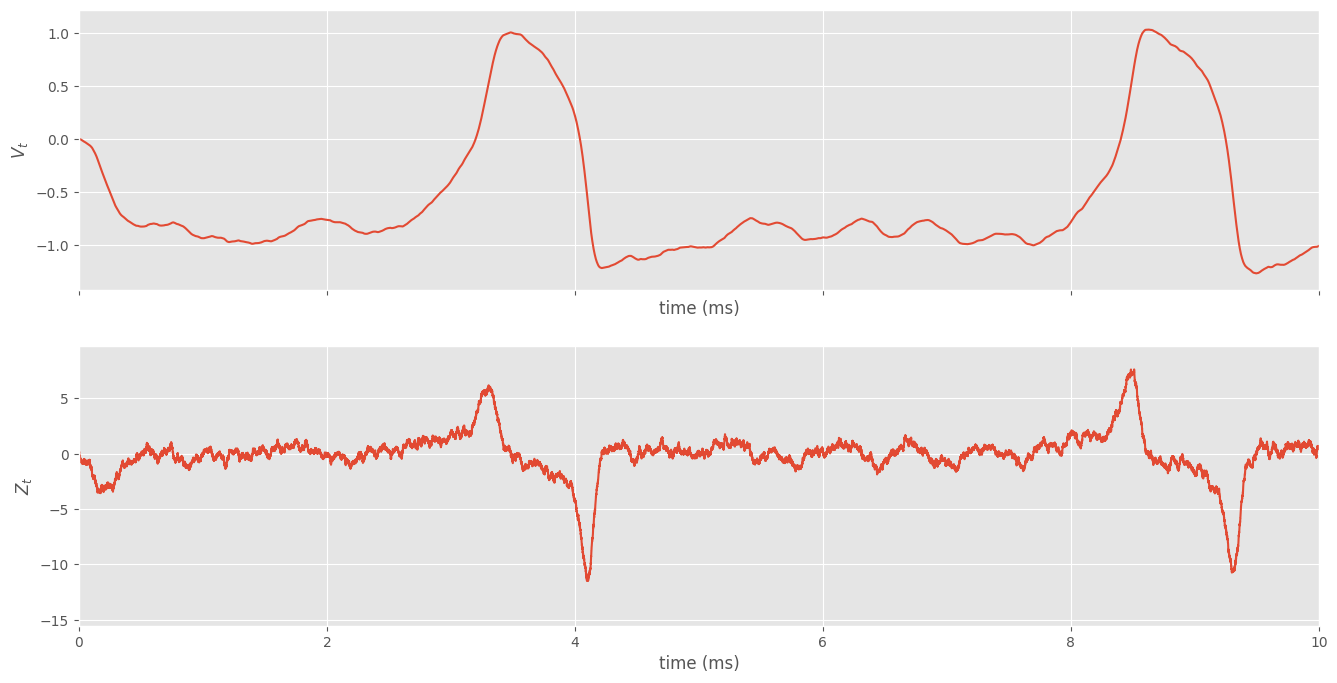

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, squeeze=True)

subsample_delta_t = 0.5
sample_rate = int(subsample_delta_t / delta_t)

axes[0].plot(times, isamples_arr[:, 0], label=r'$V_t$')
axes[1].plot(times, isamples_arr[:, 1], label=r'$Z_t$')

# axes[0].plot(times[::sample_rate], isamples_arr[:, 0][::sample_rate], 'o', markersize=5.0)
# axes[1].plot(times[::sample_rate], isamples_arr[:, 1][::sample_rate], 'o', markersize=5.0)

y_labels = [r'$V_t$', r'$Z_t$']
for ax, y_label in zip(axes, y_labels):
    ax.set_xlabel('time (ms)')
    ax.set_ylabel(y_label)
    ax.set_xlim((0, 10))

plt.show()

#### Numerical scheme bias analysis:

We now analyse whether a single step of a numerical scheme performs well in inferring the latent path:

In [11]:
# t_start = 10.0
# t_end = 10.5
# delta_t = 0.0002 
# num = int((t_end - t_start) / delta_t)
# n_samples = 10000

# idx_start = int(t_start / delta_t)
# idx_end = int(t_end / delta_t)
# x_start = np.array([[samples_arr[idx_start, 0], samples_arr[idx_start, 1]]])

# samples = sde.simulate(n_samples, t_start=t_start, t_end=t_end, x_start=x_start, num=num)

In [12]:
# n_samples_arr = np.array([samples[name] for name in samples.dtype.names])
# v_end_points = n_samples_arr[-1, :, 0]
# u_end_points = n_samples_arr[-1, :, 1]

In [13]:
# v_end_points.mean(), v_end_points.std(), u_end_points.mean(), u_end_points.std()

#### Compare to Euler-Maruyama method

In [14]:
# step = t_end - t_start

# # Compute drift and diffusion
# drift = sde.b(t_start, x_start)  # (1, 2)
# diffusion = sde.sigma(t_start, x_start)  # (1, 2, 2)
# # Generate Brownian increments
# dW = np.sqrt(step) * stats.norm.rvs(size=(n_samples, sde.dimW)) # (n_samples, 2)
# # Euler-Maruyama update
# x_step = x_start + drift * step + np.einsum('ijk,ik->ij', diffusion, dW)

In [15]:
# x_step[:, 1].mean(), x_step[:, 1].std()